In [60]:
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['savefig.bbox'] = 'tight'

import jaxsp as jsp

from scipy import constants as const

import matplotlib.animation as animation
from IPython.display import HTML

import Stellar_sim_funcs as SSF
import importlib
importlib.reload(SSF)


from scipy.interpolate import interp1d

from collections import defaultdict

from jaxsp.constants import h, om, hbar, Msun, GN, c, m22

from collections import defaultdict

In [61]:
m22 = 1
u = jsp.set_schroedinger_units(m22)

G = GN.value * (u.from_cm**3) / (u.from_g * u.from_s**2)

In [62]:
rho = jax.vmap(jsp.rho, in_axes=(0,None))


In [63]:
cNFWtides_params = jnp.array([
    357964808.148399 * u.from_Msun, 
    25.690207, 
    0.407461, 
    0.012670 * u.from_Kpc, 
    1.857991 * u.from_Kpc, 
    3.729259
])
density_params = jsp.init_core_NFW_tides_params_from_sample(cNFWtides_params)
r99 = jsp.enclosing_radius(0.99, density_params) # radius that encloses 99% of mass
print(r99, "kpc")
density_params

20.743367613524313 kpc


core_NFW_tides_params:
	name=236146193804778771,
	M200=1118.7951678146808,
	c=25.690207,
	n=0.407461,
	rc=0.0005960840778498662,
	rt=0.0874126954923718,
	delta=3.729259,
    Derived:
	rs=0.026822448297135815,
	g=0.4307070628318999,
	rho0=1987135.4034031027,

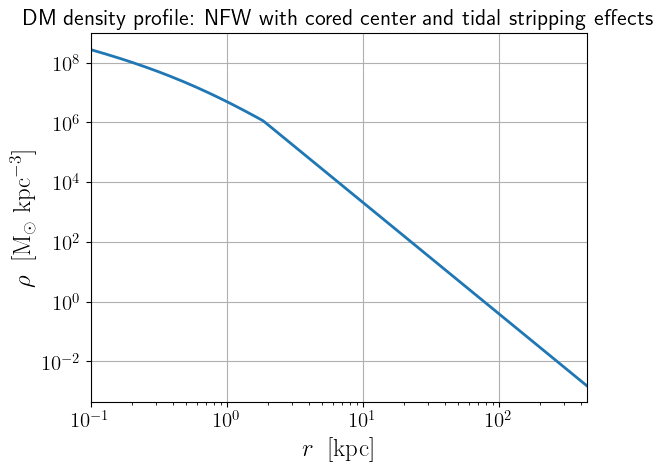

In [67]:
fig, ax = plt.subplots()
ax.xaxis.set_tick_params(labelsize=15)
ax.yaxis.set_tick_params(labelsize=15)
ax.set_xscale("log")
ax.set_yscale("log")
r = jnp.logspace(jnp.log10(100 * u.from_pc), jnp.log10(r99), 200)
ax.plot(r * u.to_Kpc, rho(r, density_params) * u.to_Msun/u.to_Kpc**3)
ax.set_ylabel(r"$\rho \;\;\mathrm{[M_\odot\;kpc^{-3}]}$", fontsize = 18)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 18)
ax.set_title('DM density profile: NFW with cored center and tidal stripping effects', fontsize = 16)
plt.show()



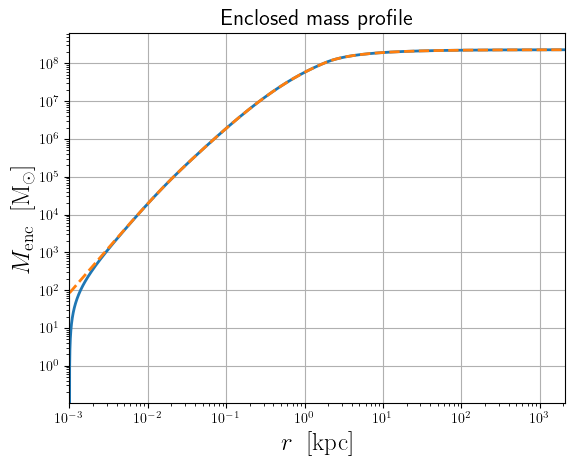

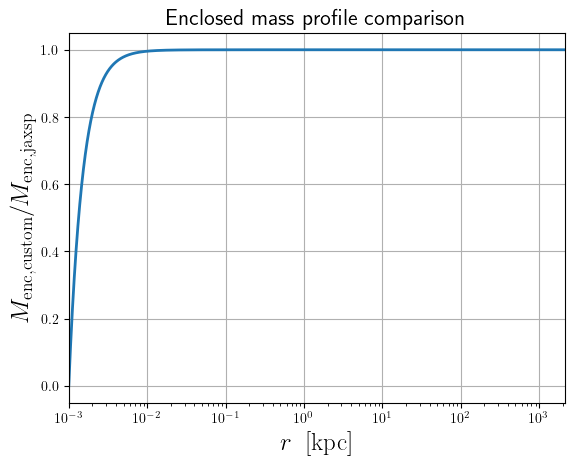

Total mass = 2.284930073759385 M_sun


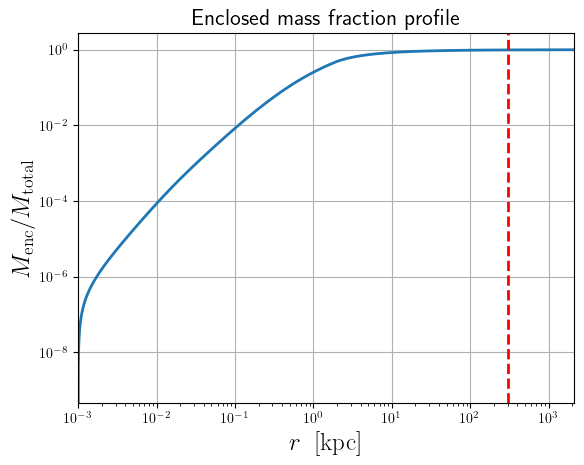

303.4133455014761 kpc
303.4133455014761 kpc


In [77]:
r = jnp.logspace(jnp.log10(1 * u.from_pc), jnp.log10(100), 10000)

rho_plot = rho(r, density_params)

M_enc = SSF.Enclosed_mass(r, rho_plot)

M_enc_jaxsp = jsp.core_nfw_tides_M(r, density_params)

fig, ax = plt.subplots()
ax.plot(r * u.to_Kpc, M_enc * u.to_Msun)
ax.plot(r * u.to_Kpc, M_enc_jaxsp * u.to_Msun, linestyle='--')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"$M_\mathrm{enc} \;\;\mathrm{[M_\odot]}$", fontsize = 18)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 18)
ax.set_title('Enclosed mass profile', fontsize = 16)
plt.show()

fig, ax = plt.subplots()
ax.plot(r * u.to_Kpc, M_enc / M_enc_jaxsp)
ax.set_xscale("log")
ax.set_ylabel(r"$M_\mathrm{enc, custom}/M_\mathrm{enc, jaxsp}$", fontsize = 18)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 18)
ax.set_title('Enclosed mass profile comparison', fontsize = 16)
plt.show()

total_mass = M_enc[-1]
print("Total mass =", total_mass * u.to_Msun * 10**-8, "M_sun")

M_fraction = M_enc / total_mass

mask = M_fraction > 0.99
r_99 = r[mask][0]

fig, ax = plt.subplots()
ax.plot(r * u.to_Kpc, M_fraction)
ax.axvline(r_99 * u.to_Kpc, 0, 1, color='red', linestyle='--', label=r'$r_{99}$')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"$M_\mathrm{enc}/M_\mathrm{total}$", fontsize = 18)
ax.set_xlabel(r"$r \;\;\mathrm{[kpc]}$", fontsize = 18)
ax.set_title('Enclosed mass fraction profile', fontsize = 16)
plt.show()

print(r_99 * u.to_Kpc, "kpc")

M_fraction_jaxsp = M_enc_jaxsp / total_mass

mask = M_fraction_jaxsp > 0.99
r_99_jaxsp = r[mask][0]
print(r_99_jaxsp * u.to_Kpc, "kpc")